## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv("dataset4.csv")
df.head()

,Annual_Income,Spending_Score,Age,Savings,Online_Spend
0,133096,58,24,38290,1766
1,98345,89,26,46541,4611
2,100391,16,36,10628,6272
3,127412,79,62,1329,1484
4,114924,90,57,39619,4503


## Check Missing Values

In [3]:
df.isnull().sum()

Annual_Income     0
Spending_Score    0
Age               0
Savings           0
Online_Spend      0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Annual_Income   500 non-null    int64
 1   Spending_Score  500 non-null    int64
 2   Age             500 non-null    int64
 3   Savings         500 non-null    int64
 4   Online_Spend    500 non-null    int64
dtypes: int64(5)
memory usage: 19.7 KB


In [5]:
df.shape

(500, 5)

df.describe()

## Check Duplicate Values

In [6]:
df.duplicated().sum()

0

In [7]:
df=df.drop_duplicates()

## EDA (Visualizations)

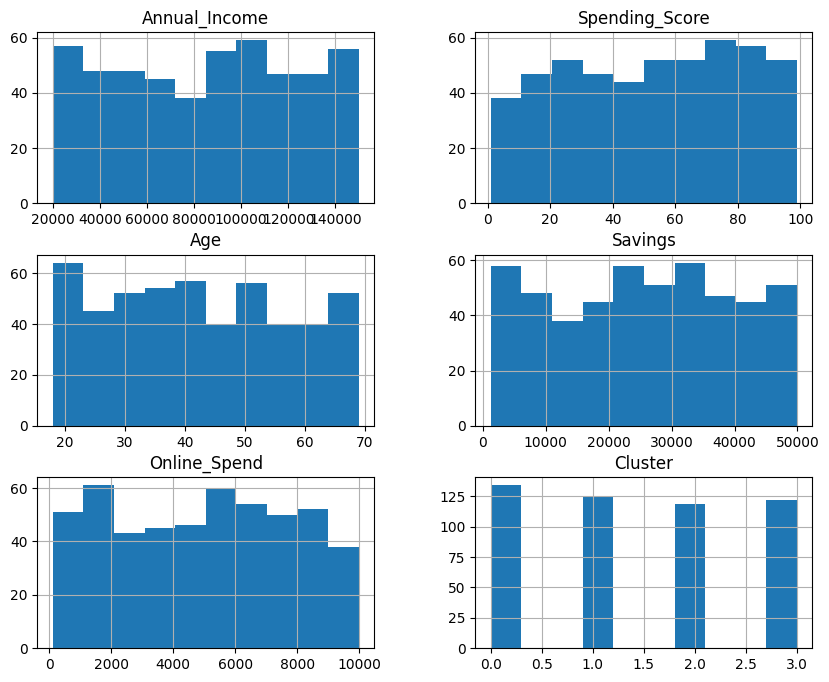

In [19]:
df.hist(figsize=(10,8))
plt.show()

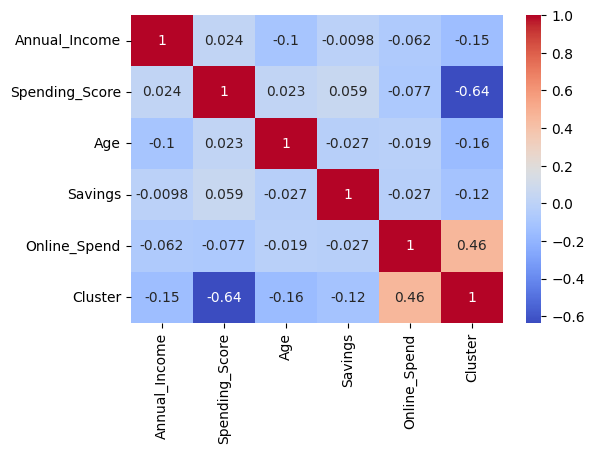

In [18]:
plt.figure(figsize=(6,4))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

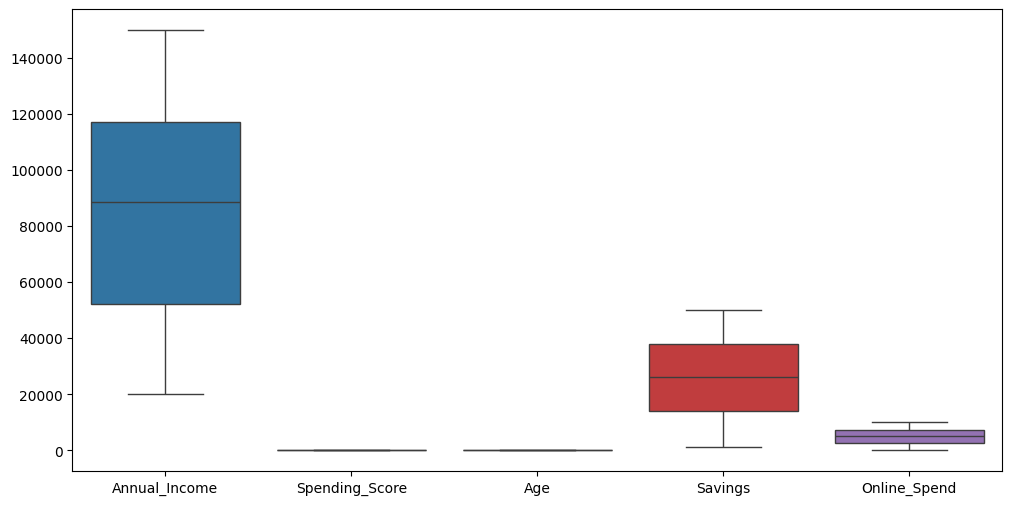

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.show()

## Normalize / Standardize Features

In [11]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

scaled_data=scaler.fit_transform(df)

scaled_data

array([[ 1.24057715,  0.2021918 , -1.24085069,  0.89429894, -1.13988975],
       [ 0.33119925,  1.31117016, -1.10591695,  1.48142808, -0.12750371],
       [ 0.38473978, -1.30029502, -0.43124824, -1.07408868,  0.46355894],
       ...,
       [-1.29071789, -0.79946608,  0.91808918, -0.21242988,  0.83328445],
       [ 0.00270738, -1.40761551, -0.49871511, -0.10540743,  0.05967206],
       [-0.02176007, -1.19297453, -0.97098321,  0.19153717,  0.51586851]])

## Elbow Method

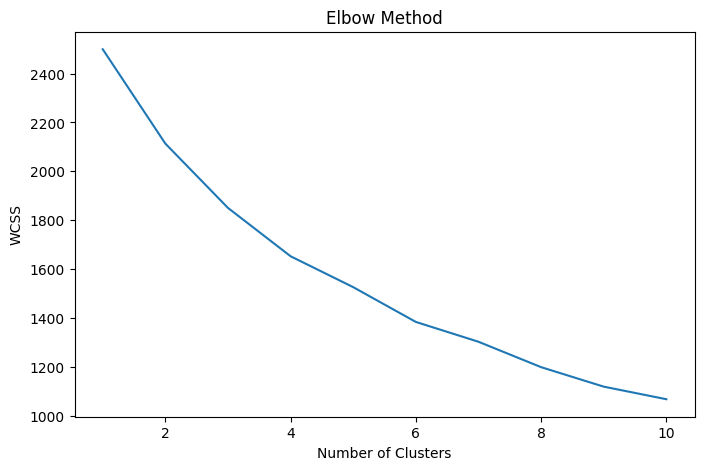

In [12]:
from sklearn.cluster import KMeans

wcss=[]

for i in range(1,11):

    kmeans=KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

## Silhouette Score

In [13]:
from sklearn.metrics import silhouette_score

for i in range(2,11):

    kmeans=KMeans(
        n_clusters=i,
        random_state=42
    )

    labels=kmeans.fit_predict(scaled_data)

    score=silhouette_score(
        scaled_data,
        labels
    )

    print(i,score)

2 0.14990092437427496
3 0.14803285684290748
4 0.15516978599993705
5 0.15778919660809765
6 0.164382866509774
7 0.1648749209102703
8 0.1664904270928318
9 0.1788563675837469
10 0.17938890720596407


## Final K-Means Model

In [14]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42
)

df["Cluster"]=kmeans.fit_predict(
    scaled_data
)

df.head()

,Annual_Income,Spending_Score,Age,Savings,Online_Spend,Cluster
0,133096,58,24,38290,1766,1
1,98345,89,26,46541,4611,1
2,100391,16,36,10628,6272,2
3,127412,79,62,1329,1484,0
4,114924,90,57,39619,4503,0


## 2D Cluster Visualization

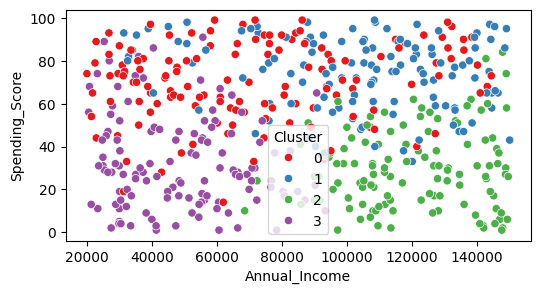

In [22]:
plt.figure(figsize=(6,3))

sns.scatterplot(
x=df["Annual_Income"],
y=df["Spending_Score"],
hue=df["Cluster"],
palette="Set1"
)

plt.show()

## 3D Visualization

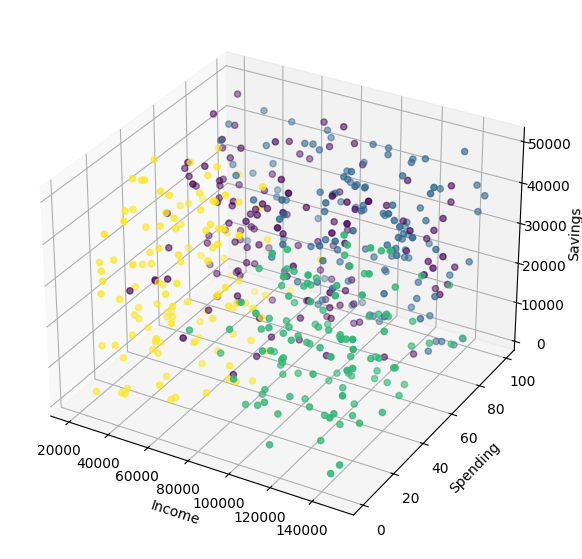

In [16]:
from mpl_toolkits.mplot3d import Axes3D

fig=plt.figure(figsize=(10,7))

ax=fig.add_subplot(
111,
projection='3d'
)

ax.scatter(
df["Annual_Income"],
df["Spending_Score"],
df["Savings"],
c=df["Cluster"]
)

ax.set_xlabel("Income")
ax.set_ylabel("Spending")
ax.set_zlabel("Savings")

plt.show()

## Interpret Business Meaning

In [17]:
cluster_summary=df.groupby(
"Cluster"
).mean()

print(cluster_summary)

         Annual_Income  Spending_Score        Age       Savings  Online_Spend
Cluster                                                                      
0         71917.567164       70.507463  52.291045  25826.723881   2598.134328
1        103957.872000       74.120000  31.848000  31742.776000   5871.992000
2        120195.084034       29.579832  42.184874  20611.621849   4966.621849
3         48437.434426       32.303279  42.524590  24424.106557   6651.459016


# Business Insights & Marketing Strategy

### Cluster 0 → High Spending Customers
#### • Annual Income: Medium (~71,918)
#### • Spending Score: High (~70)
#### • Savings: Medium
#### • Online Spend: Low

### Marketing Strategy:

#### • Loyalty programs
#### • Personalized product recommendations
#### • Premium membership offers

### Cluster 1 → Premium Customers
#### • Annual Income: Very High (~103,958)
#### • Spending Score: High (~74)
#### • Savings: High
#### • Online Spend: High

### Marketing Strategy:

#### • VIP membership
#### • Exclusive discounts
#### • Luxury product promotions

### Cluster 2 → Wealthy but Low Spending Customers
#### • Annual Income: Highest (~120,195)
#### • Spending Score: Low (~29)
#### • Savings: Low
#### • Online Spend: Medium

### Marketing Strategy:

#### • Personalized campaigns
#### • Attractive offers
#### • Encourage more purchases

### Cluster 3 → Budget Online Customers
#### • Annual Income: Low (~48,437)
#### • Spending Score: Low (~32)
#### • Online Spend: Highest (~6651)

### Marketing Strategy:

#### • Discount coupons
#### • Social media promotions
#### • Email marketing campaigns

## Conclusion for Report

"K-Means clustering was applied to segment customers into meaningful groups based on income, spending behavior, age, savings, and online spending patterns. The Elbow Method and Silhouette Score were used to determine the optimal number of clusters. Business insights and targeted marketing strategies were generated for each customer segment."